# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Joyce Abigail Gracia Zebua
- **Email:** joyceagz@student.ub.ac.id
- **ID Dicoding:** joyceagz

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah pesanan per bulan pada tahun 2016 hingga 2018, dan pada bulan apa terjadi lonjakan signifikan?
- 10 kategori produk apa yang menyumbang pendapatan tertinggi selama 2018 untuk menentukan fokus inventaris tahun depan?
- Bagaimana segmentasi pelanggan berdasarkan skor RFM (Recency, Frequency, Monetary) untuk mengidentifikasi 5% pelanggan paling loyal?
- Wilayah (state) mana yang memiliki volume transaksi tertinggi untuk mengoptimalkan strategi logistik dan pengiriman?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

## Data Wrangling

### Gathering Data

In [99]:
# Memuat semua dataset
orders_df       = pd.read_csv('orders_dataset.csv')
order_items_df  = pd.read_csv('order_items_dataset.csv')
customers_df    = pd.read_csv('customers_dataset.csv')
payments_df     = pd.read_csv('order_payments_dataset.csv')
products_df     = pd.read_csv('products_dataset.csv')
reviews_df      = pd.read_csv('order_reviews_dataset.csv')
sellers_df      = pd.read_csv('sellers_dataset.csv')
geolocation_df  = pd.read_csv('geolocation_dataset.csv')
category_df     = pd.read_csv('product_category_name_translation.csv')

# Masukkan semua dataframe ke dalam list/dictionary agar mudah diiterasi
all_df = {
    "Orders": orders_df,
    "Order Items": order_items_df,
    "Customers": customers_df,
    "Payments": payments_df,
    "Products": products_df,
    "Reviews": reviews_df,
    "Sellers": sellers_df,
    "Geolocation": geolocation_df,
    "Category Translation": category_df
}

# Menampilkan informasi dataset secara singkat untuk mengecek jumlah baris & kolom
for name, df in all_df.items():
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    display(df.head(5))
    print("\n")

Dataset: Orders
Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00




Dataset: Order Items
Shape: (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14




Dataset: Customers
Shape: (99441, 5)


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP




Dataset: Geolocation
Shape: (1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP




Dataset: Category Translation
Shape: (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- **Dataset Orders (99.441 baris):** Merupakan dataset utama yang merekam siklus hidup pesanan. Dataset ini sangat krusial untuk menganalisis tren penjualan bulanan, memantau status pengiriman, serta menghitung durasi waktu dari pemesanan hingga barang sampai ke tangan pelanggan melalui berbagai kolom timestamp yang tersedia.

- **Dataset Order Items (112.650 baris):** Dataset ini memberikan rincian setiap produk di dalam satu pesanan. Jumlah baris yang lebih besar dari dataset Orders mengindikasikan adanya transaksi yang melibatkan lebih dari satu item per pesanan. Informasi harga (price) dan biaya kirim (freight_value) di sini menjadi dasar utama dalam perhitungan total pendapatan (revenue).

- **Dataset Customers (99.441 baris):** Dataset ini menyimpan informasi demografis pelanggan. Adanya kolom customer_unique_id sangat penting untuk membedakan antara pelanggan baru dan pelanggan lama (retensi), sementara data lokasi (kota dan negara bagian) memungkinkan analisis distribusi pasar secara geografis.

- **Dataset Payments (103.886 baris):** Memberikan wawasan mengenai perilaku transaksi finansial pelanggan. Variasi jumlah baris menunjukkan adanya penggunaan metode pembayaran gabungan atau cicilan. Data ini berguna untuk mengetahui metode pembayaran yang paling populer serta rata-rata nilai transaksi (Average Order Value).

- **Dataset Products (32.951 baris):** Berisi atribut fisik dan kategori dari setiap produk yang unik. Informasi mengenai berat dan dimensi produk tersedia untuk analisis logistik, sementara kategori produk menjadi kunci dalam mengidentifikasi kelompok produk dengan performa penjualan tertinggi.

- **Dataset Reviews (99.224 baris):** Dataset ini menangkap tingkat kepuasan pelanggan melalui skor ulasan. Meskipun terdapat banyak nilai kosong (NaN) pada kolom pesan ulasan, ketersediaan skor numerik (review_score) sudah cukup kuat untuk melakukan evaluasi performa layanan dan kualitas produk secara keseluruhan.

- **Dataset Sellers (3.095 baris):** Menyediakan informasi mengenai sebaran mitra penjual di dalam platform. Data ini dapat digunakan untuk menganalisis apakah terdapat dominasi wilayah tertentu oleh penjual dan bagaimana hubungannya dengan kecepatan pengiriman barang.

- **Dataset Geolocation (1.000.163 baris):** Merupakan dataset pendukung dengan volume data yang sangat besar yang memetakan kode pos ke koordinat geografis (latitudo dan longitudo). Data ini memungkinkan pembuatan visualisasi peta yang mendalam, seperti heatmap transaksi atau analisis jarak antara penjual dan pembeli.
- **Dataset Category Translation (71 baris):** Berfungsi sebagai tabel referensi (look-up table) untuk menerjemahkan nama kategori produk dari bahasa Portugis ke bahasa Inggris. Penggunaan dataset ini memastikan hasil analisis kategori produk dapat dipahami oleh audiens yang lebih luas.

### Assessing Data

In [100]:
# Cek tipe data, missing values, duplicate data, dan inaccurate value/outlier.
for name, df in all_df.items():
    print(f"------- Assessing {name} -------")
    print(f"Dataset Information:")
    df.info()
    print(f"\nMissing Values:\n{df.isna().sum()}")
    print(f"\nDuplicated: {df.duplicated().sum()}")
    print(f"\nDescribe:\n{df.describe()}")
    print("\n" * 2)

------- Assessing Orders -------
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
o

**Insight:**

1. Dataset Orders (Tantangan Tipe Data & Missing Values)

Kesalahan Tipe Data  
Seluruh kolom bertipe timestamp seperti:
- `order_purchase_timestamp`
- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`
- `order_estimated_delivery_date`

terdeteksi sebagai **tipe data `object` (string)**.  
Kolom-kolom tersebut perlu dikonversi menjadi **tipe data `datetime`** agar analisis berbasis waktu (time series analysis) dapat dilakukan dengan benar.

Data yang Hilang  
Terdapat missing values yang cukup signifikan pada beberapa kolom logistik:

| Kolom | Jumlah Missing |
|------|------|
| `order_delivered_customer_date` | 2.965 |
| `order_delivered_carrier_date` | 1.783 |

Nilai kosong ini kemungkinan merepresentasikan:
- pesanan yang **masih diproses**
- pesanan yang **sedang dalam pengiriman**
- pesanan yang **dibatalkan**

---

2. Dataset Order Items (Konsistensi Harga & Logistik)

Statistik Deskriptif  
Kolom `price` menunjukkan **variansi yang sangat tinggi**:

- Rata-rata harga: **120,65**
- Nilai maksimum: **6.735**

Hal ini mengindikasikan adanya:
- produk **premium**
- kemungkinan **outliers**

yang perlu diperhatikan dalam analisis pendapatan.

Tipe Data  
Kolom `shipping_limit_date` masih bertipe **`object`** dan perlu dikonversi menjadi **`datetime`** untuk analisis waktu pengiriman.

---

3. Dataset Payments (Kejanggalan Nilai Transaksi)

Inaccurate Values  
Ditemukan nilai minimal **0** pada kolom berikut:

- `payment_value`
- `payment_installments`

Transaksi dengan nilai **0 rupiah** perlu diinvestigasi lebih lanjut, karena kemungkinan disebabkan oleh:
- penggunaan **voucher penuh**
- **promo khusus**
- **kesalahan sistem**

Jika tidak ditangani, data ini dapat menyesatkan perhitungan seperti **Average Order Value (AOV)**.

---

4. Dataset Products (Kelengkapan Atribut Produk)

Missing Values pada Kategori  
Terdapat **610 produk** yang tidak memiliki nilai pada kolom:

- `product_category_name`

Karena kategori merupakan dimensi penting dalam analisis penjualan, data kosong ini perlu ditangani, misalnya dengan:
- mengisi label **"Others"**
- atau **"Unknown"**

Atribut Fisik Produk  
Terdapat **2 baris data** yang kehilangan informasi terkait:
- berat produk
- dimensi produk

Kehilangan data ini dapat memengaruhi analisis terkait **biaya logistik dan pengiriman**.

---

5. Dataset Reviews (Karakteristik Ulasan Pelanggan)

Dominasi Data Kosong  
Kolom berikut memiliki tingkat missing values yang sangat tinggi:

| Kolom | Missing Values |
|------|------|
| `review_comment_title` | 87.656 |
| `review_comment_message` | 58.247 |

Hal ini menunjukkan bahwa sebagian besar pelanggan:
- hanya memberikan **rating (bintang)**
- tanpa menuliskan **judul atau komentar ulasan**

---

6. Dataset Geolocation (Isu Duplikasi Data)

Duplikasi Data  
Dataset ini memiliki tingkat duplikasi yang sangat tinggi dengan total:

**261.831 baris duplikat**

Pembersihan data duplikat sangat penting sebelum melakukan:
- **analisis spasial**
- **visualisasi peta (mapping)**

Tujuannya adalah untuk:
- menghindari **pemborosan memori**
- mencegah **distorsi pada visualisasi data**

---

7. Dataset Customers & Sellers (Integritas Data Tinggi)

Kualitas Data  
Dataset **Customers** dan **Sellers** menunjukkan kualitas data yang sangat baik:

- Tidak ditemukan **missing values**
- Tidak terdapat **baris duplikat**

Dataset ini siap digunakan untuk analisis seperti:
- analisis **demografi pelanggan**
- analisis **distribusi penjual**

---

8. Dataset Category Translation (Referensi Kategori)

Kualitas Data  
Dataset referensi ini memiliki:

- **71 kategori unik**
- Tidak terdapat **missing values**
- Tidak terdapat **duplikasi**

### Cleaning Data

1. **Mengubah Tipe Data Kolom Tanggal (Datetime).** Masalah: Banyak kolom tanggal di Orders, Order Items, dan Reviews yang masih bertipe object.

In [101]:
# List kolom tanggal pada tabel Orders
datetime_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

# Mengubah tipe data menjadi datetime
for column in datetime_columns_orders:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Mengubah tipe data tanggal pada tabel lainnya
order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])
reviews_df["review_creation_date"] = pd.to_datetime(reviews_df["review_creation_date"])
reviews_df["review_answer_timestamp"] = pd.to_datetime(reviews_df["review_answer_timestamp"])

2. **Menangani Missing Values.** Masalah: Kolom kategori di Products dan komentar di Reviews memiliki nilai kosong.

In [102]:
# Pada Products, isi kategori yang kosong dengan "others"
products_df["product_category_name"].fillna("others", inplace=True)

# Pada Reviews, isi judul dan pesan yang kosong dengan "no comment"
reviews_df["review_comment_title"].fillna("no title", inplace=True)
reviews_df["review_comment_message"].fillna("no comment", inplace=True)

# Untuk dataset Orders, baris yang memiliki nilai kosong pada kolom tanggal pengiriman diasumsikan sebagai pesanan yang belum sampai atau belum selesai diproses,
# sehingga data tersebut tidak dihapus maupun diisi.

/tmp/ipykernel_9374/2305996990.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_category_name"].fillna("others", inplace=True)
/tmp/ipykernel_9374/2305996990.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

3. **Menangani Duplikasi Data (Khusus Geolocation).** Masalah: Terdapat lebih dari 260 ribu baris duplikat di Geolocation.

In [103]:
# Menghapus duplikasi pada geolocation_df
geolocation_df.drop_duplicates(inplace=True)

4. **Menangani Inaccurate Values (Outliers).** Masalah: Terdapat nilai payment_value 0 atau harga yang sangat ekstrem.

In [104]:
# Untuk memfokuskan analisis hanya pada transaksi yang valid (di atas 0)
payments_df = payments_df[payments_df["payment_value"] > 0]

**Verifikasi Hasil Cleaning**

In [105]:
# Verifikasi Hasil Cleaning
print("Verifikasi Orders:")
print(orders_df.info()) # Cek tipe datetime

print("\nVerifikasi Products:")
print(f"Missing Values Kategori: {products_df['product_category_name'].isna().sum()}")

print("\nVerifikasi Geolocation:")
print(f"Jumlah Duplikasi: {geolocation_df.duplicated().sum()}")

print("\nVerifikasi Payments:")
print(f"Nilai Minimal Pembayaran: {payments_df['payment_value'].min()}")

display(orders_df)

Verifikasi Orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB
None

Verifikasi Products:
Missing Values Kategori: 0

Verifikasi Geolocation:
Jumlah Duplikasi: 0

Verifikasi Payments:
Nilai Minimal Pembayara

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


**Insight:**
- Standardisasi Tipe Data: Melakukan konversi seluruh kolom yang merepresentasikan waktu dari tipe object menjadi datetime. Langkah ini sangat krusial untuk memungkinkan analisis berbasis waktu (time-series analysis) seperti melihat tren penjualan bulanan.

- Imputasi Missing Values: Mengatasi kekosongan data pada dataset produk dengan memberikan label "others" pada kategori yang tidak teridentifikasi. Hal ini dilakukan untuk menjaga integritas data agar produk tersebut tetap dapat disertakan dalam visualisasi kategori tanpa menyebabkan error atau ketidakkonsistenan.

- Penanganan Data Duplikat: Melakukan pembersihan data ganda secara masif pada dataset geolocation. Langkah ini bertujuan untuk mengoptimalkan performa komputasi dan memastikan pemetaan geografis tidak terdistorsi oleh data yang berulang.

- Filter Nilai Transaksi: Melakukan filtrasi pada dataset pembayaran untuk memastikan hanya transaksi dengan nilai positif yang disertakan dalam analisis, guna menjaga keakuratan perhitungan metrik finansial.

## Exploratory Data Analysis (EDA)

### Explore Analisis Univariat: Distribusi Harga dan Ongkos Kirim (Mendeteksi Outlier)

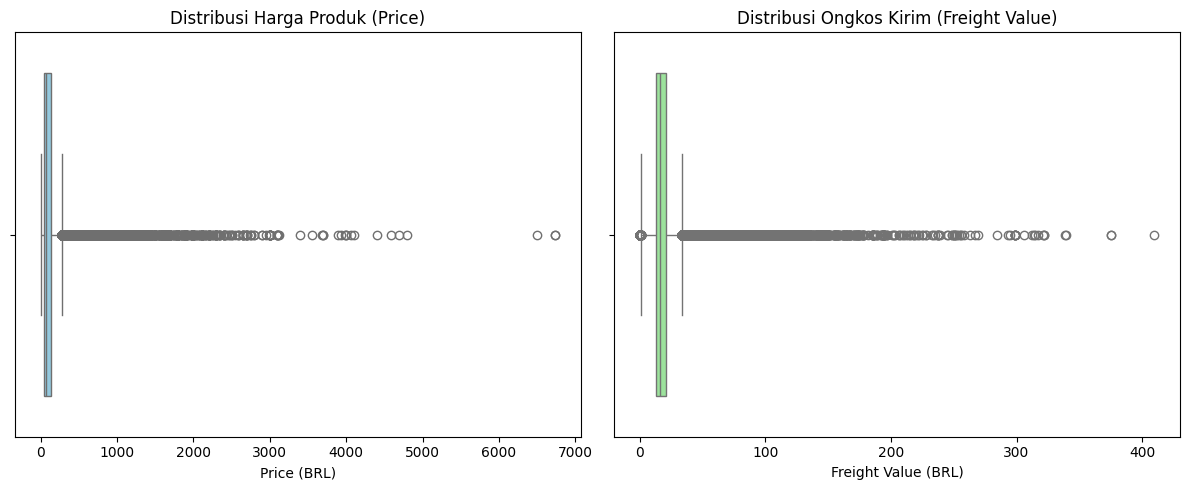

In [106]:
plt.figure(figsize=(12, 5))

# Boxplot untuk Price
plt.subplot(1, 2, 1)
sns.boxplot(x=order_items_df['price'], color='skyblue')
plt.title('Distribusi Harga Produk (Price)')
plt.xlabel('Price (BRL)')

# Boxplot untuk Freight Value (Ongkos Kirim)
plt.subplot(1, 2, 2)
sns.boxplot(x=order_items_df['freight_value'], color='lightgreen')
plt.title('Distribusi Ongkos Kirim (Freight Value)')
plt.xlabel('Freight Value (BRL)')

plt.tight_layout()
plt.show()

**Insight:**
- Melalui boxplot, terlihat jelas adanya sebaran outlier ekstrem di sisi kanan pada harga produk (hingga > 6000 BRL) dan ongkos kirim. Informasi ini penting sebagai catatan bahwa nilai mean (rata-rata) pada dataset ini rentan terdistorsi, sehingga penggunaan median mungkin lebih bijak untuk analisis lanjutan.

### Explore Analisis Univariat: Distribusi Skor Ulasan Pelanggan

/tmp/ipykernel_9374/520239119.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews_df, x='review_score', palette='viridis')


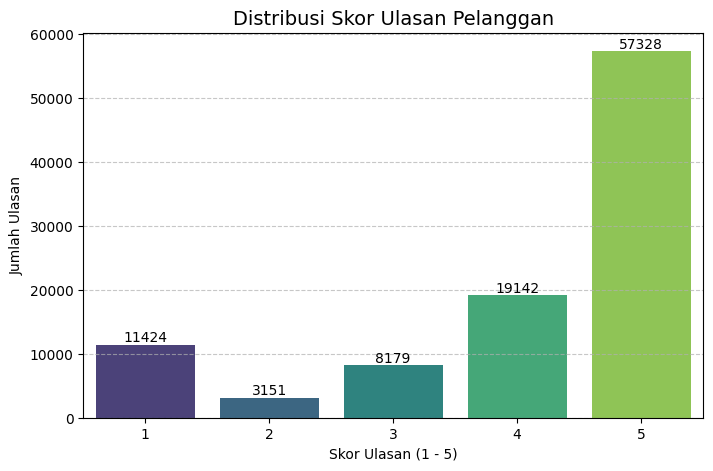

In [107]:
plt.figure(figsize=(8, 5))
sns.countplot(data=reviews_df, x='review_score', palette='viridis')

plt.title('Distribusi Skor Ulasan Pelanggan', fontsize=14)
plt.xlabel('Skor Ulasan (1 - 5)')
plt.ylabel('Jumlah Ulasan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan label angka di atas setiap bar
ax = plt.gca()
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height(), '%d' % int(p.get_height()),
            fontsize=10, color='black', ha='center', va='bottom')

plt.show()

**Insight:**
- Visualisasi ini langsung menyoroti ketimpangan ekstrem (polarisasi) antara kepuasan maksimal (skor 5) dan ketidakpuasan total (skor 1), sementara skor 2 dan 3 sangat minim.

### Explore Analisis Tren (Time Series): Pergerakan Pesanan Bulanan

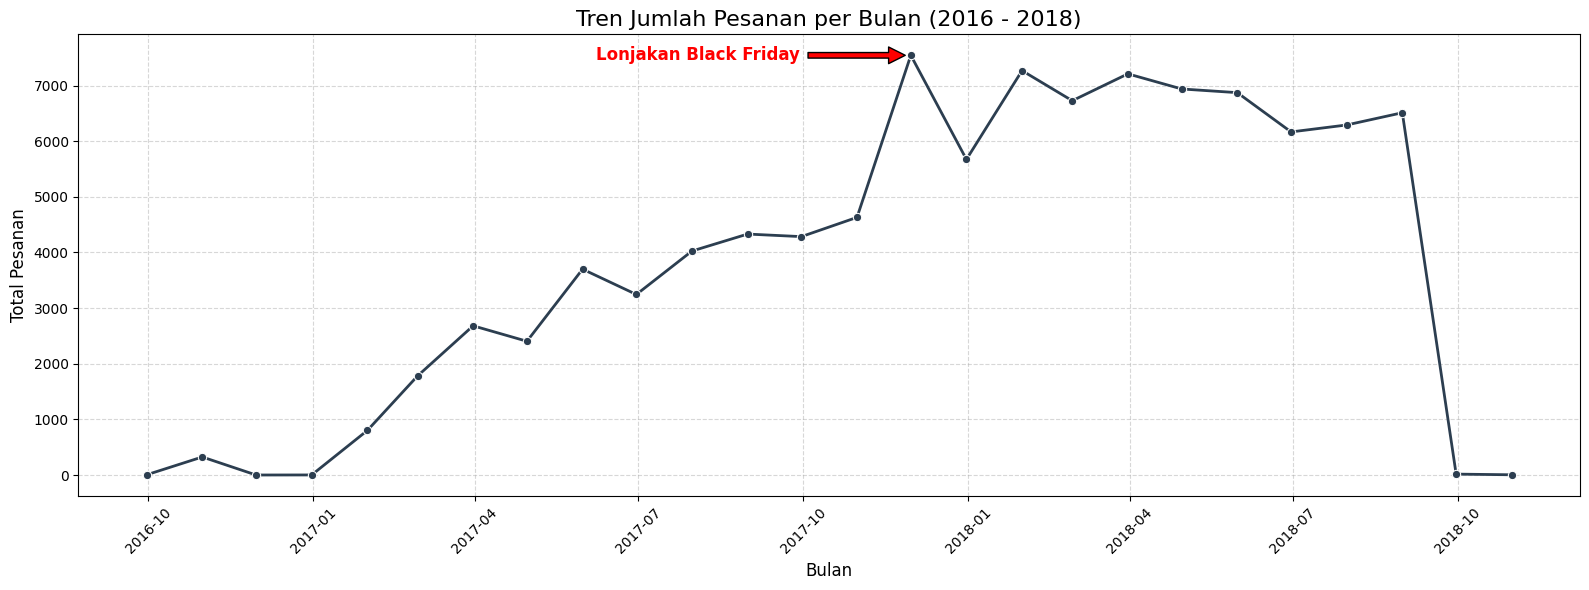

In [108]:
monthly_orders_df = orders_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "customer_id": "nunique"
}).rename(columns={"order_id": "order_count"}).reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_orders_df, x='order_purchase_timestamp', y='order_count',
             marker='o', linewidth=2, color='#2c3e50')

plt.title('Tren Jumlah Pesanan per Bulan (2016 - 2018)', fontsize=16)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Pesanan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Menandai titik puncak (Black Friday)
max_order = monthly_orders_df['order_count'].max()
max_month = monthly_orders_df[monthly_orders_df['order_count'] == max_order]['order_purchase_timestamp'].values[0]

plt.annotate('Lonjakan Black Friday',
             xy=(max_month, max_order),
             xytext=(-80, 0),
             textcoords='offset points',
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, color='red', weight='bold',
             ha='right',
             va='center')

plt.tight_layout()
plt.show()

**Insight:**
- Efektivitas Kampanye Black Friday: Promosi Black Friday (November 2017) terbukti menjadi katalis utama penjualan, menghasilkan rekor puncak pesanan tertinggi hingga menyentuh angka lebih dari 7.000 pesanan dalam satu bulan.

- Peningkatan Baseline Penjualan (Retensi Baik): Meskipun terjadi penurunan sesaat setelah bulan promosi Black Friday (Desember 2017), volume pesanan sepanjang tahun 2018 stabil di angka yang jauh lebih tinggi (rata-rata 6.000+ pesanan/bulan) dibandingkan rata-rata sebelum periode Black Friday. Ini mengindikasikan bahwa bisnis berhasil mempertahankan pelanggan baru yang diakuisisi selama periode promosi.

- Pertumbuhan Organik yang Sehat: Sebelum lonjakan Black Friday, bisnis sudah menunjukkan tren pertumbuhan organik yang sangat baik dan konsisten secara bertahap dari Januari 2017 hingga Oktober 2017.

- Anomali Data di Akhir 2018: Terdapat penurunan yang sangat drastis (hampir menyentuh angka 0) pada akhir periode (sekitar September - Oktober 2018). Dalam konteks analisis data, ini biasanya bukan berarti bisnis tiba-tiba bangkrut, melainkan indikasi bahwa data pada bulan terakhir tersebut belum terekam atau ditarik secara penuh (incomplete data) saat dataset dibuat.

### Explore Analisis Bivariat: Performa Kategori (Volume vs Pendapatan)

,product_category_name_english,order_id
7,bed_bath_table,9417
43,health_beauty,8836
68,sports_leisure,7720
15,computers_accessories,6689
39,furniture_decor,6449
49,housewares,5884
73,watches_gifts,5624
71,telephony,4199
5,auto,3897
72,toys,3886


,product_category_name_english,total_revenue
43,health_beauty,1258681.34
73,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
68,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


/tmp/ipykernel_9374/2420330054.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_category_sales, x='order_id', y='product_category_name_english',
/tmp/ipykernel_9374/2420330054.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_revenue_df, x='total_revenue', y='product_category_name_english',


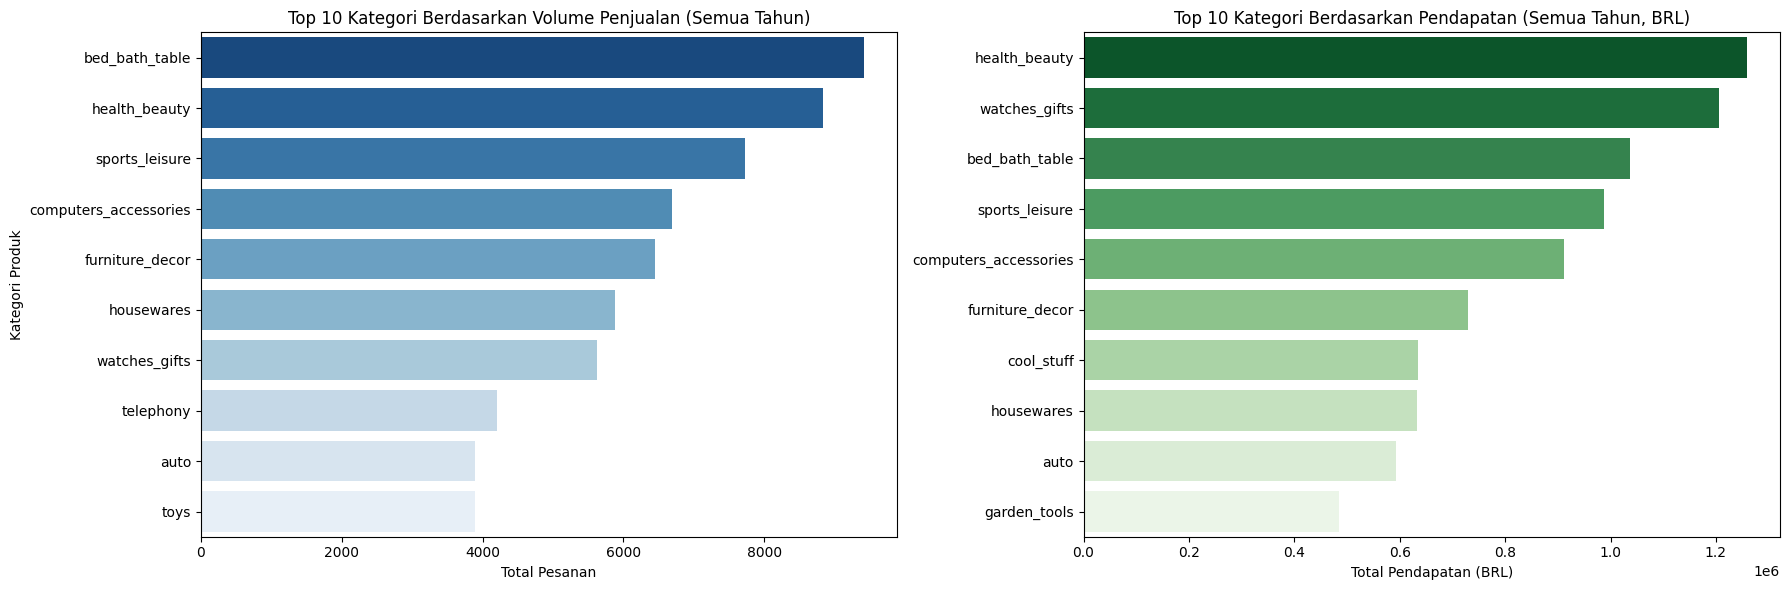

In [109]:
# Gabungkan dataframe yang relevan untuk mendapatkan kategori dan harga
merged_df = pd.merge(orders_df, order_items_df, on='order_id', how='inner')
merged_df = pd.merge(merged_df, products_df, on='product_id', how='left')
merged_df = pd.merge(merged_df, category_df, on='product_category_name', how='left')
merged_df['product_category_name_english'] = merged_df['product_category_name_english'].fillna(merged_df['product_category_name'])

# Agregasi: Top 10 Kategori berdasarkan Volume Penjualan (semua tahun)
top_category_sales = merged_df.groupby('product_category_name_english')['order_id'].nunique().reset_index()
top_category_sales = top_category_sales.sort_values(by='order_id', ascending=False).head(10)

# Agregasi: Top 10 Kategori berdasarkan Pendapatan (semua tahun)
top_10_revenue_df = merged_df.groupby('product_category_name_english')['price'].sum().reset_index()
top_10_revenue_df = top_10_revenue_df.rename(columns={'price': 'total_revenue'})
top_10_revenue_df = top_10_revenue_df.sort_values(by='total_revenue', ascending=False).head(10)

display(top_category_sales)
display(top_10_revenue_df)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Top 10 by Volume
sns.barplot(data=top_category_sales, x='order_id', y='product_category_name_english',
            palette='Blues_r', ax=ax[0])
ax[0].set_title('Top 10 Kategori Berdasarkan Volume Penjualan (Semua Tahun)')
ax[0].set_xlabel('Total Pesanan')
ax[0].set_ylabel('Kategori Produk')

# Chart 2: Top 10 by Revenue
sns.barplot(data=top_10_revenue_df, x='total_revenue', y='product_category_name_english',
            palette='Greens_r', ax=ax[1])
ax[1].set_title('Top 10 Kategori Berdasarkan Pendapatan (Semua Tahun, BRL)')
ax[1].set_xlabel('Total Pendapatan (BRL)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Insight:**
- Kategori dengan Performa Paling Optimal: Kategori health_beauty merupakan kategori paling berharga bagi bisnis. Kategori ini tidak hanya sangat diminati (peringkat 2 dalam volume pesanan), tetapi juga sukses menjadi penyumbang pendapatan tertinggi (peringkat 1). Ini menunjukkan keseimbangan yang luar biasa antara tingginya permintaan pelanggan dan harga jual produk.

- Karakteristik High-Ticket Items (Nilai Jual Tinggi): Terdapat pola yang sangat mencolok pada kategori watches_gifts. Meskipun dari segi kuantitas pesanan hanya berada di peringkat ke-7, kategori ini mampu melesat ke peringkat ke-2 sebagai penyumbang pendapatan terbesar. Hal ini mengindikasikan bahwa produk di kategori ini memiliki Average Order Value (AOV) atau harga per unit yang jauh lebih tinggi dibandingkan kategori lain (kemungkinan besar karena barang premium/mewah).

- Traffic Builder vs. Revenue Generator: Kategori bed_bath_table bertindak sebagai penggerak traffic utama. Kategori ini memimpin jauh di peringkat 1 untuk urusan volume pesanan, namun secara pendapatan turun ke peringkat 3. Ini adalah karakteristik umum untuk produk kebutuhan rumah tangga esensial: frekuensi pembeliannya sangat tinggi, namun harga per unitnya cenderung lebih rendah.

- Strategi Bundling & Cross-Selling: Memahami perbedaan karakteristik di atas, sebuah strategi bundling bisa diterapkan. Misalnya, menjadikan produk bed_bath_table sebagai "umpan" promosi untuk mendatangkan banyak transaksi, lalu menawarkan cross-selling atau rekomendasi produk health_beauty pada saat checkout untuk mendongkrak margin pendapatan secara keseluruhan.

### Explore Analisis Spasial/Demografi: Volume Pesanan Berdasarkan Wilayah


Top 10 State dengan Jumlah Pesanan Terbanyak:


,customer_state,order_count
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


/tmp/ipykernel_9374/1821308708.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_states, x='customer_state', y='order_count', palette='magma')


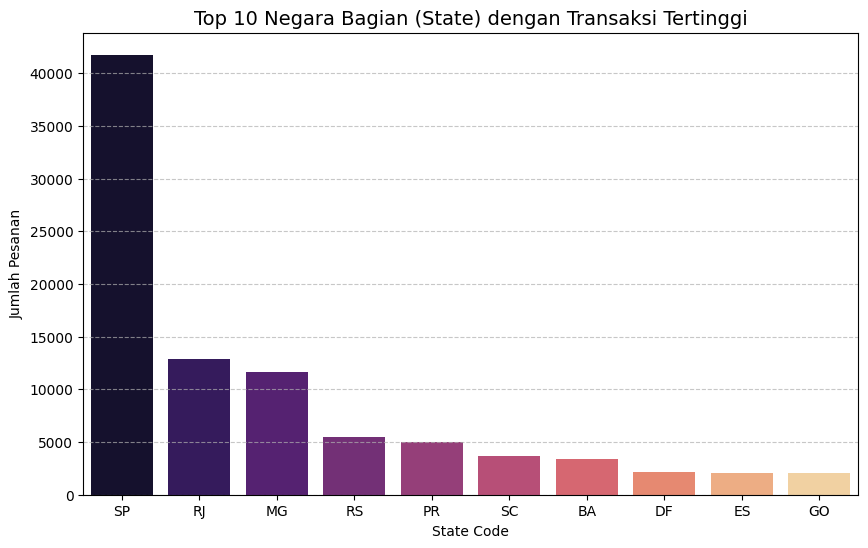

In [110]:
# Menggabungkan data orders dengan customers
orders_customers_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="inner",
    on="customer_id"
)

# Menghitung jumlah pesanan unik per state
state_orders_summary = orders_customers_df.groupby("customer_state")['order_id'].nunique().reset_index()
state_orders_summary.rename(columns={'order_id': 'order_count'}, inplace=True)

# Top 10 state dengan transaksi tertinggi
top_10_states = state_orders_summary.sort_values(by='order_count', ascending=False).head(10)

print("Top 10 State dengan Jumlah Pesanan Terbanyak:")
display(top_10_states)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_states, x='customer_state', y='order_count', palette='magma')

plt.title('Top 10 Negara Bagian (State) dengan Transaksi Tertinggi', fontsize=14)
plt.xlabel('State Code')
plt.ylabel('Jumlah Pesanan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Dominasi Signifikan Negara Bagian São Paulo (SP): Pasar e-commerce menunjukkan tingkat konsentrasi yang sangat tinggi di SP. Dengan jumlah pesanan melebihi 40.000 transaksi, SP berkontribusi sekitar tiga hingga empat kali lebih besar dibandingkan negara bagian peringkat kedua, yaitu RJ. Kondisi ini menunjukkan bahwa SP berperan sebagai pasar inti (core market) yang menjadi penopang utama kinerja penjualan bisnis.

- Pusat Aktivitas di Wilayah Tenggara Brasil: Tiga negara bagian dengan kontribusi transaksi tertinggi (SP, RJ, dan MG) seluruhnya berada di wilayah Tenggara Brasil. Hal ini mengindikasikan bahwa tingkat adopsi e-commerce serta daya beli konsumen cenderung terkonsentrasi pada kawasan yang menjadi pusat aktivitas ekonomi dan memiliki kepadatan penduduk yang tinggi.

- Kesenjangan Volume Transaksi (Pola Long-Tail): Setelah tiga negara bagian teratas, terlihat adanya penurunan volume transaksi yang cukup tajam. Negara bagian yang berada pada peringkat keempat hingga kesepuluh (RS hingga GO) menunjukkan jumlah pesanan yang jauh lebih rendah dan relatif stabil, dengan volume transaksi umumnya berada di bawah 6.000 pesanan.

- Implikasi Strategis terhadap Infrastruktur Logistik: Berdasarkan konsentrasi volume transaksi yang tinggi di wilayah SP, RJ, dan MG, penempatan infrastruktur logistik utama seperti main warehouse atau fulfillment center di sekitar wilayah SP merupakan strategi yang rasional. Pendekatan ini berpotensi menurunkan biaya pengiriman secara signifikan sekaligus meningkatkan efisiensi waktu pengiriman (Service Level Agreement/SLA) bagi sebagian besar pelanggan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan per bulan pada tahun 2016 hingga 2018, dan pada bulan apa terjadi lonjakan signifikan?

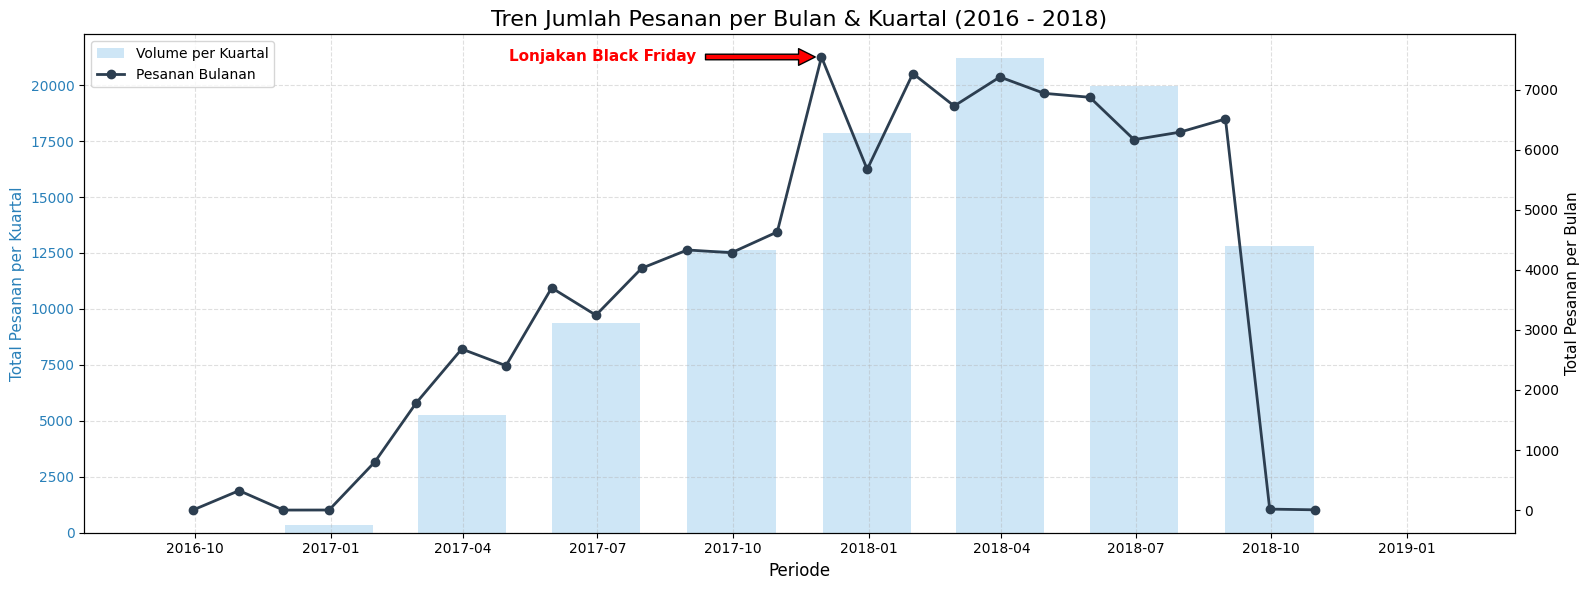

In [111]:
# Agregasi bulanan (sudah dibuat di EDA, tapi di-rerun di sini untuk kemandirian cell)
monthly_orders_df = orders_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "order_id": "nunique"
}).rename(columns={"order_id": "order_count"}).reset_index()

# Agregasi kuartalan untuk bar chart
quarterly_orders_df = orders_df.resample(rule='QE', on='order_purchase_timestamp').agg({
    "order_id": "nunique"
}).rename(columns={"order_id": "order_count"}).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 6))

# Bar chart volume per kuartal (background)
ax1.bar(quarterly_orders_df['order_purchase_timestamp'],
        quarterly_orders_df['order_count'],
        width=60, color='#aed6f1', alpha=0.6, label='Volume per Kuartal')
ax1.set_ylabel('Total Pesanan per Kuartal', fontsize=11, color='#2980b9')
ax1.tick_params(axis='y', labelcolor='#2980b9')

# Line chart bulanan (overlay)
ax2 = ax1.twinx()
ax2.plot(monthly_orders_df['order_purchase_timestamp'],
         monthly_orders_df['order_count'],
         marker='o', linewidth=2, color='#2c3e50', label='Pesanan Bulanan')
ax2.set_ylabel('Total Pesanan per Bulan', fontsize=11)

# Tandai puncak Black Friday
max_order = monthly_orders_df['order_count'].max()
max_month = monthly_orders_df[monthly_orders_df['order_count'] == max_order]['order_purchase_timestamp'].values[0]

ax2.annotate('Lonjakan Black Friday',
             xy=(max_month, max_order),
             xytext=(-90, 0),
             textcoords='offset points',
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=11, color='red', weight='bold',
             ha='right', va='center')

plt.title('Tren Jumlah Pesanan per Bulan & Kuartal (2016 - 2018)', fontsize=16)
ax1.set_xlabel('Periode', fontsize=12)
plt.xticks(rotation=45)
ax1.grid(True, linestyle='--', alpha=0.4)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

**Insight:**

- Tren jumlah pesanan dari akhir tahun 2016 hingga pertengahan 2018 secara umum menunjukkan pertumbuhan organik yang sangat positif dan konsisten. Dimulai dari volume yang sangat rendah di akhir 2016, pesanan terus merangkak naik secara bertahap sepanjang tahun 2017. Setelah mencapai puncaknya, performa penjualan di tahun 2018 berhasil stabil di angka rata-rata bulanan yang jauh lebih tinggi dibandingkan tahun sebelumnya.

- Lonjakan pesanan paling signifikan (peak) terjadi pada bulan November 2017, yang secara spesifik ditandai sebagai "Lonjakan Black Friday", di mana total pesanan meroket hingga menembus angka 7.000 pesanan dalam satu bulan.

### Pertanyaan 2: 10 kategori produk apa yang menyumbang pendapatan tertinggi selama 2018 untuk menentukan fokus inventaris tahun depan?

/tmp/ipykernel_9374/2004187686.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_volume_2018, x='order_id', y='product_category_name_english',
/tmp/ipykernel_9374/2004187686.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_revenue_2018, x='total_revenue', y='product_category_name_english',


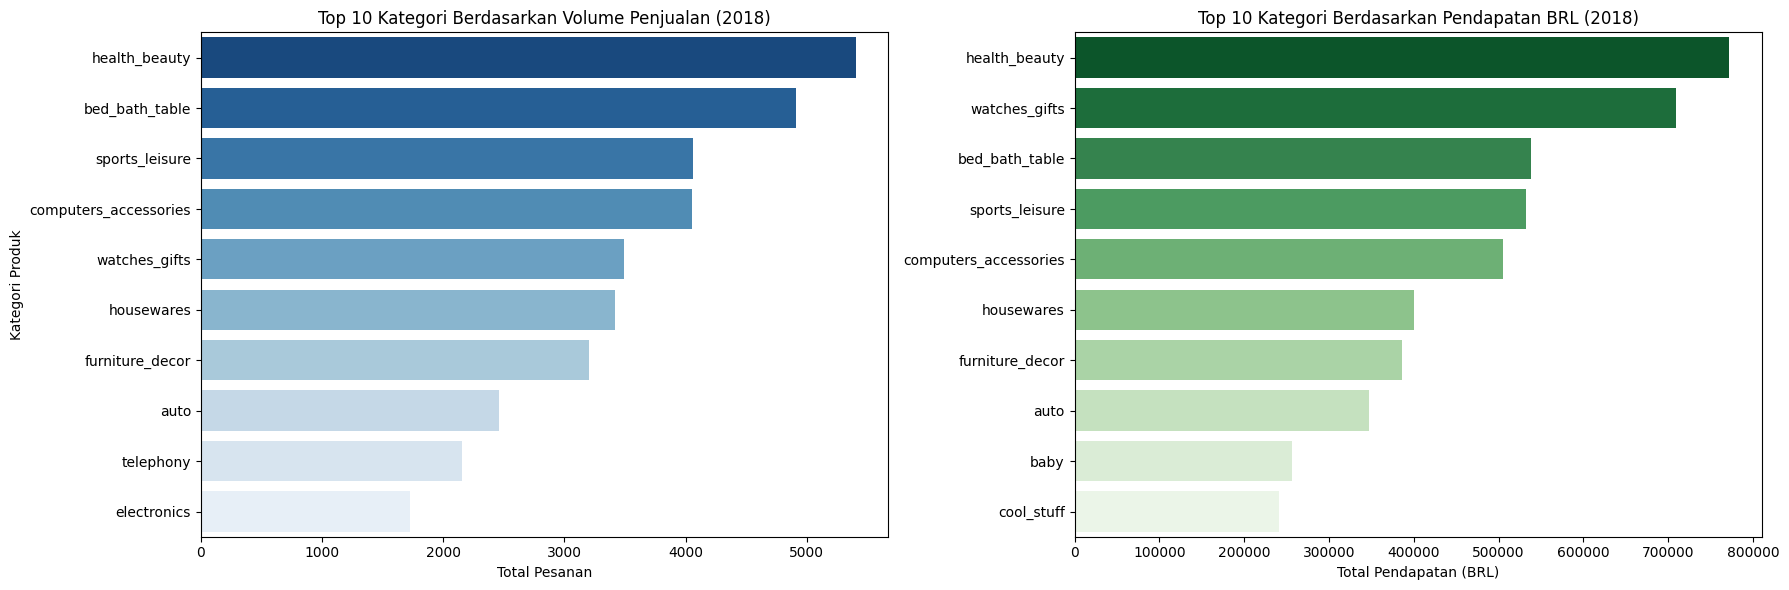

In [112]:
# Filter pesanan khusus untuk tahun 2018
orders_2018_df = orders_df[orders_df['order_purchase_timestamp'].dt.year == 2018]

# Gabungkan dengan item, produk, dan kategori
merged_2018_df = pd.merge(orders_2018_df, order_items_df, on='order_id', how='inner')
merged_2018_df = pd.merge(merged_2018_df, products_df, on='product_id', how='left')
merged_2018_df = pd.merge(merged_2018_df, category_df, on='product_category_name', how='left')
merged_2018_df['product_category_name_english'] = merged_2018_df['product_category_name_english'].fillna(merged_2018_df['product_category_name'])

# Agregasi: Top 10 berdasarkan Volume (2018)
top_volume_2018 = merged_2018_df.groupby('product_category_name_english')['order_id'].nunique().reset_index()
top_volume_2018 = top_volume_2018.sort_values(by='order_id', ascending=False).head(10)

# Agregasi: Top 10 berdasarkan Pendapatan (2018)
top_revenue_2018 = merged_2018_df.groupby('product_category_name_english')['price'].sum().reset_index()
top_revenue_2018 = top_revenue_2018.rename(columns={'price': 'total_revenue'})
top_revenue_2018 = top_revenue_2018.sort_values(by='total_revenue', ascending=False).head(10)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=top_volume_2018, x='order_id', y='product_category_name_english',
            palette='Blues_r', ax=ax[0])
ax[0].set_title('Top 10 Kategori Berdasarkan Volume Penjualan (2018)')
ax[0].set_xlabel('Total Pesanan')
ax[0].set_ylabel('Kategori Produk')

sns.barplot(data=top_revenue_2018, x='total_revenue', y='product_category_name_english',
            palette='Greens_r', ax=ax[1])
ax[1].set_title('Top 10 Kategori Berdasarkan Pendapatan BRL (2018)')
ax[1].set_xlabel('Total Pendapatan (BRL)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Insight:**

- Dominasi Mutlak Kategori Health & Beauty: Berbeda dengan tren keseluruhan (all-time) di mana bed_bath_table merajai volume, khusus di tahun 2018, kategori health_beauty sukses menguasai peringkat 1 di kedua metrik sekaligus (Volume Pesanan dan Pendapatan). Ini menunjukkan adanya lonjakan tren perawatan diri dan kecantikan yang sangat masif di tahun 2018. Kategori ini adalah superstar bisnis Anda saat ini.

- Kekuatan High-Ticket Items (Watches & Gifts): Kategori watches_gifts kembali membuktikan dirinya sebagai "mesin uang". Meskipun secara volume pesanan hanya berada di peringkat ke-5, kategori ini berhasil melesat ke peringkat 2 sebagai penyumbang pendapatan terbesar (menempel ketat health_beauty di angka > 700.000 BRL). Produk di kategori ini memiliki margin/harga jual rata-rata (AOV) yang sangat tinggi.

- Pergeseran Traffic Builder: Kategori bed_bath_table yang sebelumnya (secara all-time) merupakan penyumbang volume nomor 1, kini turun ke peringkat 2 di tahun 2018. Meski demikian, bersama dengan sports_leisure dan computers_accessories, ketiganya tetap menjadi pilar utama yang menjaga arus transaksi (traffic) harian tetap stabil.

- Perbedaan Pemain Bawah (Volume vs Revenue): Jika Anda perhatikan di urutan terbawah, kategori telephony dan electronics menyumbang banyak pesanan (masuk Top 10 Volume), tetapi gagal masuk ke Top 10 Pendapatan. Sebaliknya, kategori baby dan cool_stuff masuk ke Top 10 Pendapatan meskipun volumenya tidak masuk 10 besar. Ini berarti produk bayi dan "cool stuff" harganya lebih premium dibanding produk telepon/elektronik dasar yang dijual.

- Rekomendasi Fokus Inventaris Tahun Depan:

   - Prioritas Utama (Stok & Promosi): Tingkatkan alokasi budget pengadaan barang dan kampanye pemasaran secara maksimal untuk health_beauty, karena kategori ini terbukti paling diminati dan paling menguntungkan sepanjang tahun 2018.

   - Fokus Retensi Margin: Jaga ketersediaan stok eksklusif untuk watches_gifts. Anda tidak perlu menjual barang ini dalam kuantitas sebanyak sabun mandi, tetapi pastikan barangnya selalu ada karena setiap penjualannya memberikan suntikan pendapatan yang sangat besar.

   - Ketersediaan Produk Esensial: Pastikan rantai pasok untuk bed_bath_table, sports_leisure, dan computers_accessories tetap aman untuk menjaga baseline volume transaksi harian platform Anda.

## Analisis Lanjutan (Opsional)

### Pertanyaan 3: Bagaimana segmentasi pelanggan berdasarkan skor RFM (Recency, Frequency, Monetary) untuk mengidentifikasi 5% pelanggan paling loyal?

Ambang batas skor RFM untuk masuk Top 5% adalah: 13.0
Jumlah pelanggan di kelompok Top 5%: 8279 pelanggan

Top 10 Pelanggan Paling Loyal:


,customer_unique_id,recency,frequency,monetary,R_Score,M_Score,F_Score,RFM_Total
26456,46450c74a0d8c5ca9395da1daac6c120,61,3,9553.02,5,5,5,15
75266,c8460e4251689ba205045f3ea17884a1,71,4,4655.91,5,5,5,15
89382,edde2314c6c30e864a128ac95d6b2112,75,1,4513.32,5,5,5,15
93317,f886a3f43af9ac928fbb4b56436c528c,64,1,3076.13,5,5,5,15
96080,fff5eb4918b2bf4b2da476788d42051c,108,1,2844.96,5,5,5,15
90591,f140f377d666848e3712b51a2734d120,80,1,2713.36,5,5,5,15
92895,f755e02e22f99b9e1658cbd2186a212d,73,1,2419.20,5,5,5,15
91105,f2a29b4d4c04184a9372bb7374d344ac,98,1,2404.72,5,5,5,15
86812,e6fad5b1c79a4760aac5068d09c46535,54,1,2328.40,5,5,5,15
93902,fa094305fdb6062436c99adba7d53dde,93,1,2267.28,5,5,5,15


/tmp/ipykernel_9374/1930088568.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm_summary, x='RFM_Total', palette='viridis')


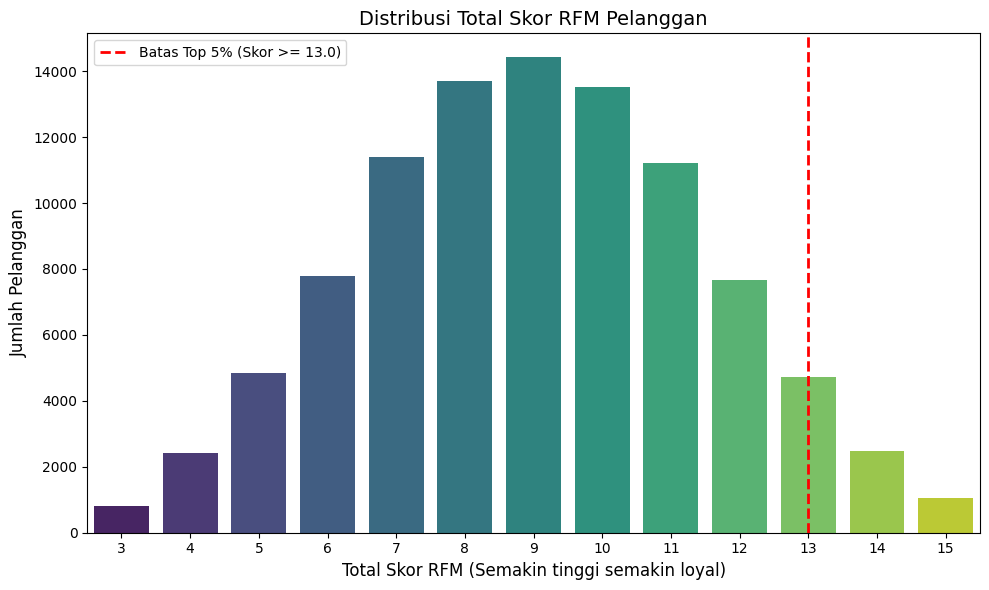

In [113]:
# Menggabungkan data orders, customers, dan payments
rfm_df = pd.merge(orders_df, customers_df, on="customer_id", how="inner")

# Agregasi payment_value per order_id (menghindari duplikasi akibat cicilan)
order_payments = payments_df.groupby('order_id')['payment_value'].sum().reset_index()
rfm_df = pd.merge(rfm_df, order_payments, on="order_id", how="inner")

# Tanggal referensi untuk perhitungan Recency
recent_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Menghitung metrik R, F, M per pelanggan unik
rfm_summary = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
rfm_summary.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

# Membuat skor RFM berskala 1-5 (5 = terbaik)
rfm_summary['R_Score'] = pd.qcut(rfm_summary['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm_summary['M_Score'] = pd.qcut(rfm_summary['monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Frequency: pakai rank() karena mayoritas pelanggan hanya belanja 1x (duplicate bins)
rfm_summary['F_Score'] = pd.qcut(rfm_summary['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

rfm_summary['RFM_Total'] = rfm_summary[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# Mengidentifikasi Top 5% pelanggan paling loyal
top_5_threshold = rfm_summary['RFM_Total'].quantile(0.95)
top_5_customers = rfm_summary[rfm_summary['RFM_Total'] >= top_5_threshold].sort_values(
    by=['RFM_Total', 'monetary'], ascending=[False, False]
)

print(f"Ambang batas skor RFM untuk masuk Top 5% adalah: {top_5_threshold}")
print(f"Jumlah pelanggan di kelompok Top 5%: {len(top_5_customers)} pelanggan\n")
print("Top 10 Pelanggan Paling Loyal:")
display(top_5_customers.head(10))

# Visualisasi distribusi skor RFM
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm_summary, x='RFM_Total', palette='viridis')

plt.title('Distribusi Total Skor RFM Pelanggan', fontsize=14)
plt.xlabel('Total Skor RFM (Semakin tinggi semakin loyal)', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)

plt.axvline(x=int(top_5_threshold) - 3, color='red', linestyle='--', linewidth=2,
            label=f'Batas Top 5% (Skor >= {top_5_threshold})')
plt.legend()
plt.tight_layout()
plt.show()


**Insight:**

- Distribusi Mayoritas Pelanggan (Mid-Tier Segment): Grafik distribusi skor RFM menunjukkan bahwa sebagian besar pelanggan berada pada rentang skor total 8 hingga 10. Hal ini menunjukkan bahwa mayoritas pengguna platform termasuk dalam kategori pelanggan menengah: mereka masih aktif melakukan transaksi, tetapi frekuensi pembelian dan nilai transaksi belum berada pada tingkat tertinggi.

- Kelompok Pelanggan dengan Nilai RFM Tertinggi: Berdasarkan perhitungan kuantil, ambang skor RFM untuk kelompok pelanggan dengan performa tertinggi berada pada skor ≥ 13, dengan total 8.279 pelanggan yang memenuhi kriteria tersebut. Kelompok ini memiliki kombinasi skor recency yang baik (relatif baru bertransaksi), frekuensi pembelian lebih tinggi dibanding pelanggan lain, serta total nilai pembelian yang besar.

- Karakteristik Pelanggan Bernilai Tinggi: Pelanggan dengan skor RFM tertinggi menunjukkan kombinasi performa yang kuat pada ketiga dimensi RFM. Mereka cenderung memiliki aktivitas transaksi yang lebih baru, nilai belanja yang lebih besar, dan secara relatif lebih sering melakukan pembelian dibandingkan pelanggan pada kelompok skor menengah.

- Implikasi Strategi Bisnis: Kelompok pelanggan dengan skor RFM tinggi merupakan segmen bernilai tinggi bagi bisnis, sehingga penting untuk mempertahankan mereka melalui strategi seperti program loyalitas, promosi eksklusif, atau rekomendasi produk yang lebih personal. Dengan menjaga hubungan dengan segmen ini, perusahaan dapat mempertahankan kontribusi pendapatan yang signifikan dari pelanggan yang paling aktif.

### Pertanyaan 4: Wilayah (state) mana yang memiliki volume transaksi tertinggi untuk mengoptimalkan strategi logistik dan pengiriman?

/tmp/ipykernel_9374/3535299780.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_states, y='customer_state', x='order_count', palette='magma', ax=ax2,


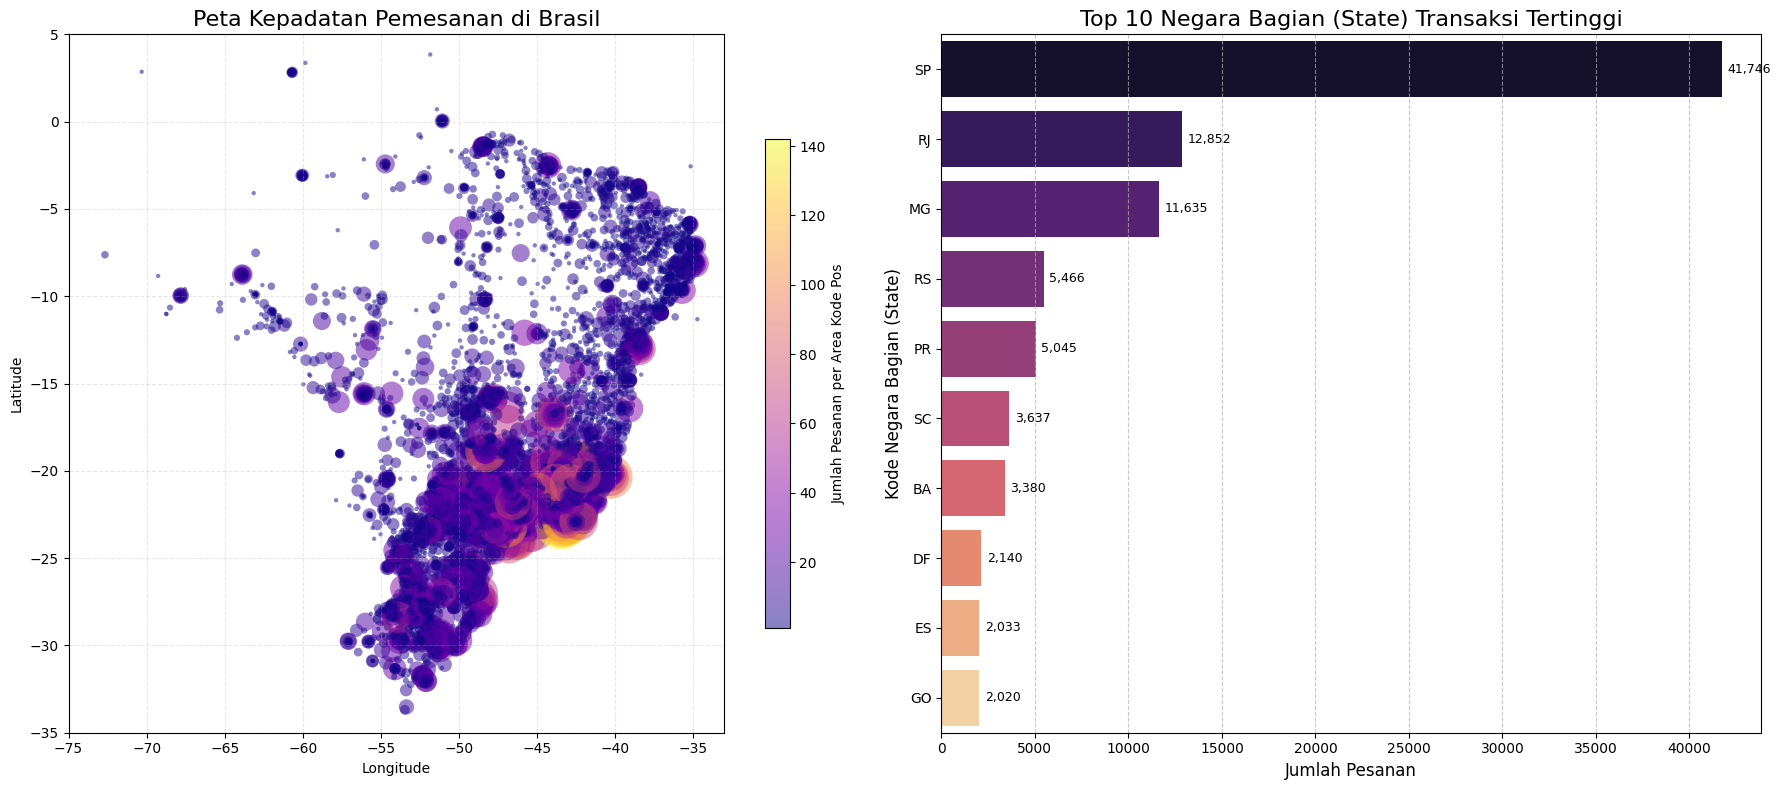

Data Transaksi 5 Negara Bagian Teratas:


,customer_state,order_count
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045


In [114]:
# Menyiapkan data geolokasi: rata-rata koordinat per kode pos
orders_cust = pd.merge(orders_df, customers_df, on='customer_id', how='inner')

zip_order_counts = orders_cust.groupby('customer_zip_code_prefix')['order_id'].nunique().reset_index()
zip_order_counts.rename(columns={'order_id': 'order_count'}, inplace=True)

avg_geo = geolocation_df.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

geo_plot_data = pd.merge(zip_order_counts, avg_geo,
                         left_on='customer_zip_code_prefix',
                         right_on='geolocation_zip_code_prefix',
                         how='inner')

# Visualisasi ganda: Scatter Map + Bar Chart Top 10 State
fig = plt.figure(figsize=(18, 8))

# Plot 1: Scatter plot kepadatan pesanan per koordinat
ax1 = fig.add_subplot(1, 2, 1)
scatter = ax1.scatter(geo_plot_data['geolocation_lng'], geo_plot_data['geolocation_lat'],
            alpha=0.5,
            s=geo_plot_data['order_count'] * 10,
            c=geo_plot_data['order_count'],
            cmap='plasma',
            edgecolors='none')

ax1.set_title('Peta Kepadatan Pemesanan di Brasil', fontsize=16)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_xlim(-75, -33)
ax1.set_ylim(-35, 5)

cbar = fig.colorbar(scatter, ax=ax1, shrink=0.7)
cbar.set_label('Jumlah Pesanan per Area Kode Pos')

# Plot 2: Bar Chart Top 10 State (horizontal untuk keterbacaan)
ax2 = fig.add_subplot(1, 2, 2)
sns.barplot(data=top_10_states, y='customer_state', x='order_count', palette='magma', ax=ax2,
            orient='h')

# Tambahkan label nilai di ujung setiap bar
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width()):,}',
                 xy=(p.get_width(), p.get_y() + p.get_height() / 2),
                 xytext=(4, 0), textcoords='offset points',
                 va='center', fontsize=9)

ax2.set_title('Top 10 Negara Bagian (State) Transaksi Tertinggi', fontsize=16)
ax2.set_ylabel('Kode Negara Bagian (State)', fontsize=12)
ax2.set_xlabel('Jumlah Pesanan', fontsize=12)
ax2.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Data Transaksi 5 Negara Bagian Teratas:")
display(top_10_states.head())

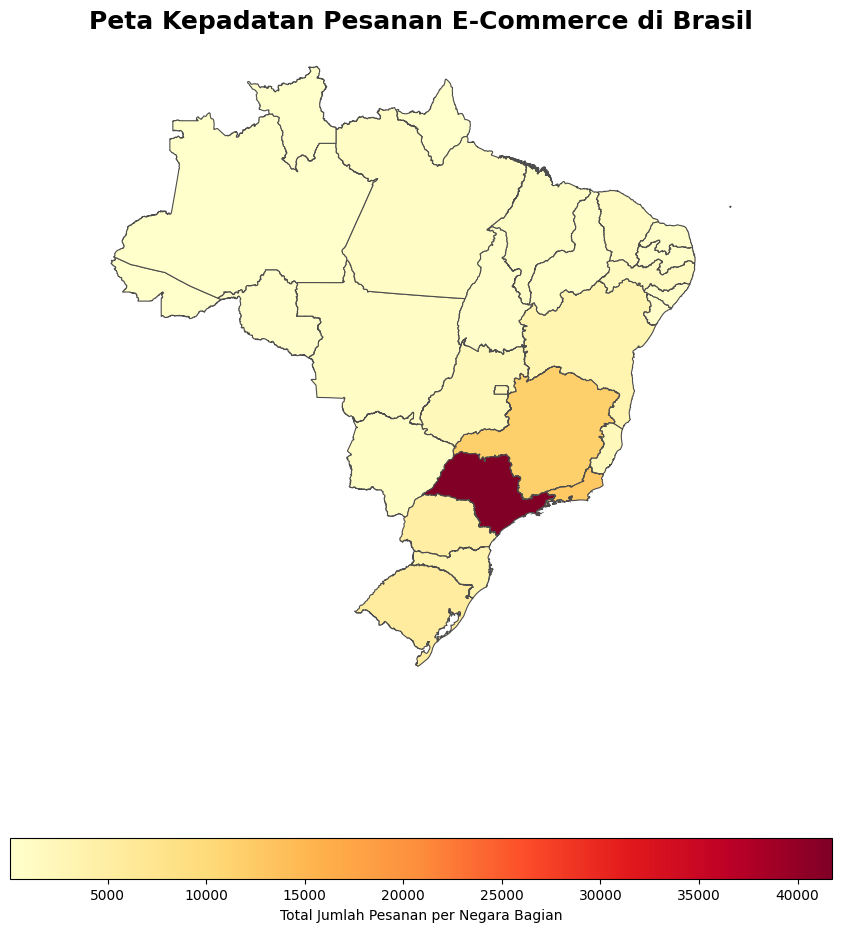

In [116]:
# Mengambil data GeoJSON peta Brasil dari repositori publik
url_geojson = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil_map = gpd.read_file(url_geojson)

# Menggabungkan data pesanan per state dengan data peta
# Kolom singkatan state pada GeoJSON ini bernama 'sigla'
map_data = brazil_map.merge(state_orders_summary, left_on='sigla', right_on='customer_state', how='left')
map_data['order_count'] = map_data['order_count'].fillna(0)

# Choropleth Map
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

map_data.plot(column='order_count',
              cmap='YlOrRd',
              linewidth=0.8,
              ax=ax,
              edgecolor='0.3',
              legend=True,
              legend_kwds={'label': "Total Jumlah Pesanan per Negara Bagian",
                           'orientation': "horizontal",
                           'shrink': 0.6})

ax.set_title('Peta Kepadatan Pesanan E-Commerce di Brasil', fontsize=18, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()
plt.show()


**Insight:**

- Konsentrasi Geografis Transaksi: Visualisasi scatter plot dan choropleth map menunjukkan bahwa distribusi pesanan e-commerce di Brasil tidak merata secara geografis. Kepadatan transaksi cenderung terkonsentrasi di wilayah Tenggara hingga Selatan Brasil, sementara wilayah Utara dan sebagian Barat Tengah menunjukkan jumlah pesanan yang relatif lebih rendah. Hal ini terlihat dari kepadatan titik pada scatter plot yang lebih dominan di wilayah tersebut serta intensitas warna yang lebih tinggi pada peta choropleth.

- Dominasi Negara Bagian São Paulo: Negara bagian São Paulo (SP) memiliki jumlah pesanan tertinggi dengan 41.746 transaksi, jauh melampaui negara bagian lainnya. Posisi berikutnya ditempati oleh Rio de Janeiro (RJ) dengan 12.852 pesanan dan Minas Gerais (MG) dengan 11.635 pesanan. Perbedaan ini menunjukkan bahwa SP merupakan pusat aktivitas e-commerce paling signifikan dalam dataset.

- Konsentrasi Aktivitas di Wilayah Tenggara: Tiga negara bagian dengan jumlah transaksi tertinggi—São Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG)—berada di wilayah Tenggara Brasil. Konsentrasi ini menunjukkan bahwa kawasan tersebut memiliki tingkat aktivitas e-commerce yang lebih tinggi dibandingkan wilayah lain, yang kemungkinan dipengaruhi oleh faktor seperti kepadatan penduduk, tingkat urbanisasi, serta perkembangan infrastruktur ekonomi dan digital.

- Implikasi bagi Strategi Bisnis: Pola distribusi transaksi ini menunjukkan bahwa wilayah dengan aktivitas transaksi tinggi, khususnya di region Tenggara, dapat menjadi fokus utama dalam strategi operasional dan distribusi. Dengan memahami konsentrasi permintaan pelanggan, perusahaan dapat mempertimbangkan pengelolaan distribusi dan logistik yang lebih efisien untuk melayani area dengan volume pesanan terbesar.

## Conclusion

Conclusion 1: Bagaimana tren jumlah pesanan per bulan pada tahun 2016 hingga 2018, dan pada bulan apa terjadi lonjakan signifikan?
- Tren jumlah pesanan menunjukkan pertumbuhan yang konsisten dan positif sejak akhir tahun 2016 hingga pertengahan 2018. Peningkatan paling mencolok terjadi pada November 2017, yang bertepatan dengan periode promosi Black Friday. Kampanye tersebut tidak hanya menghasilkan rekor jumlah pesanan dalam satu bulan, tetapi juga berkontribusi pada peningkatan tingkat dasar (baseline) penjualan secara berkelanjutan sepanjang tahun 2018, yang mengindikasikan adanya retensi pelanggan yang lebih baik setelah periode promosi.

Conclusion 2: 10 kategori produk apa yang menyumbang pendapatan tertinggi selama 2018 untuk menentukan fokus inventaris tahun depan?

- Kategori Health & Beauty menjadi kontributor utama sepanjang tahun 2018, menempati posisi teratas baik dari segi volume penjualan maupun total pendapatan. Oleh karena itu, kategori ini perlu menjadi prioritas utama dalam perencanaan alokasi stok dan strategi promosi pada tahun berikutnya. Selain itu, kategori Watches & Gifts memiliki nilai transaksi yang relatif tinggi sehingga berperan penting dalam menjaga margin keuntungan, sementara kategori Bed Bath Table berkontribusi signifikan dalam menjaga stabilitas volume transaksi harian.

Conclusion 3: Bagaimana segmentasi pelanggan berdasarkan skor RFM (Recency, Frequency, Monetary) untuk mengidentifikasi 5% pelanggan paling loyal?

- Berdasarkan analisis RFM, pelanggan yang termasuk dalam kelompok 5% teratas atau segmen Champions umumnya memiliki total skor minimal ≥ 13,0. Sebanyak 8.279 pelanggan berada dalam kategori ini dan menunjukkan karakteristik berupa frekuensi pembelian yang tinggi, transaksi yang relatif baru, serta kontribusi pendapatan yang besar terhadap perusahaan. Dengan demikian, perusahaan disarankan untuk mempertahankan segmen pelanggan bernilai tinggi ini melalui program loyalitas premium atau insentif eksklusif, karena biaya mempertahankan pelanggan loyal cenderung lebih efisien dibandingkan memperoleh pelanggan baru.

Conclusion 4: Wilayah (state) mana yang memiliki volume transaksi tertinggi untuk mengoptimalkan strategi logistik dan pengiriman?

- Negara bagian São Paulo (SP) merupakan wilayah dengan volume transaksi tertinggi secara nasional, diikuti oleh Rio de Janeiro (RJ) dan Minas Gerais (MG), yang semuanya berada di kawasan Tenggara Brasil. Berdasarkan pola distribusi tersebut, strategi logistik yang disarankan adalah penerapan model Hub-and-Spoke, yaitu dengan menempatkan pusat gudang utama (main fulfillment center) di wilayah São Paulo untuk menekan biaya pengiriman secara signifikan. Gudang satelit dapat ditempatkan di RJ dan MG guna mempercepat distribusi regional, sementara layanan logistik pihak ketiga (3PL) dapat dimanfaatkan untuk menjangkau wilayah dengan cakupan distribusi yang masih terbatas, khususnya di kawasan Utara dan Barat.

Rekomendasi (Action Items):

- Optimasi Promosi Musiman: Fokuskan kampanye promosi pada periode dengan lonjakan permintaan, terutama menjelang Black Friday, serta menyiapkan stok produk lebih awal untuk mengantisipasi peningkatan pesanan.

- Prioritas Inventaris Produk Utama: Tingkatkan ketersediaan stok pada kategori dengan kontribusi pendapatan terbesar seperti Health & Beauty, serta kategori bernilai tinggi lainnya seperti Watches & Gifts dan Bed Bath Table.

- Program Retensi Pelanggan Bernilai Tinggi: Terapkan program loyalitas atau promosi eksklusif bagi pelanggan dengan skor RFM tinggi (≥13) untuk mempertahankan pelanggan yang memberikan kontribusi pendapatan terbesar.

- Optimalisasi Distribusi Logistik: Fokuskan pusat distribusi di wilayah dengan volume transaksi tertinggi, terutama São Paulo, serta memanfaatkan gudang regional atau layanan logistik pihak ketiga untuk menjangkau wilayah lain secara efisien.

